In [34]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


Task 4 — Train Tree Based Models

Exported modelling data from R and switched to python for building decision tree classifiers.

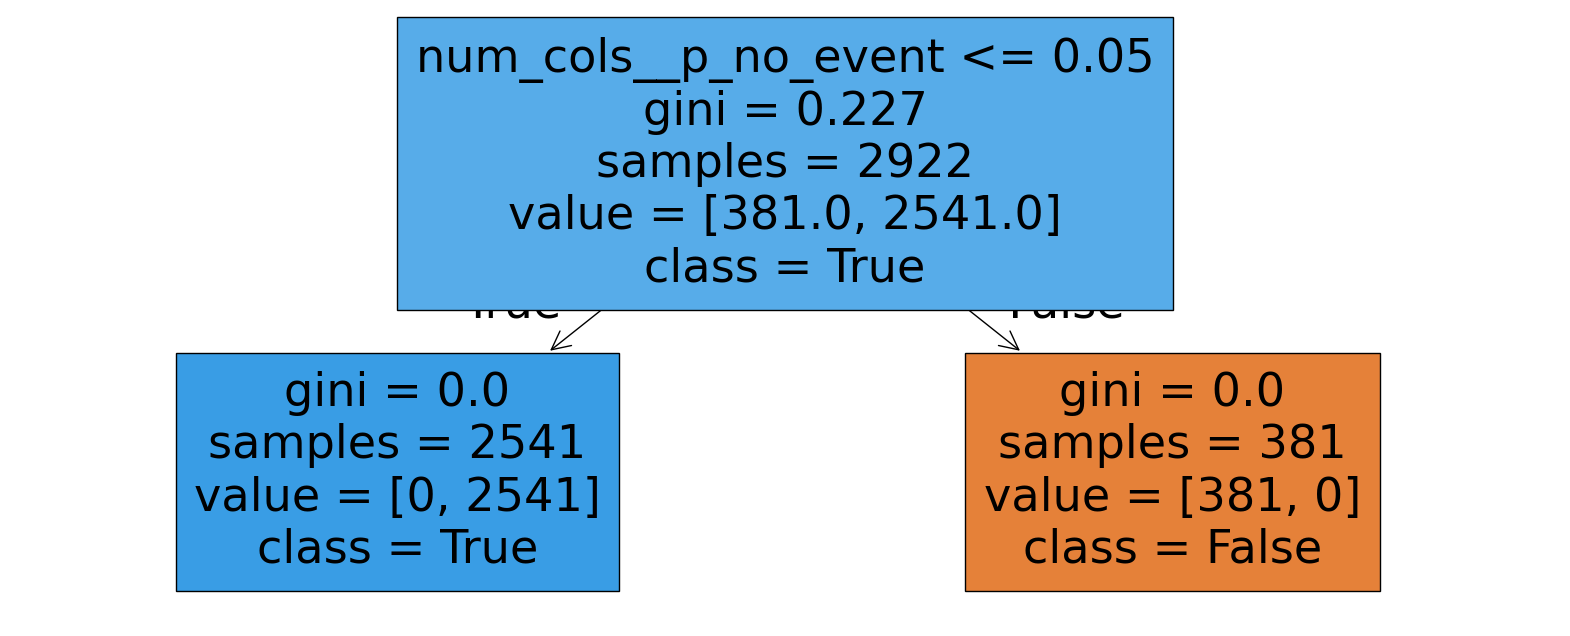

In [14]:
from os import pread
df = pd.read_csv('/content/churn_modelling_data.csv')
df.head() # inspect first few rows



# Split features from targets

x = df.drop(columns=['churn'])
y = df['churn']

# transform cols

cat_cols = x.select_dtypes(include=['object',"category"]).columns
num_cols = x.select_dtypes(exclude=['object','category']).columns

# pre_process

pre_process = ColumnTransformer(transformers=[
    ('num_cols', 'passthrough', num_cols),
    ('cat_cols', OneHotEncoder(handle_unknown='ignore'), cat_cols) # Added handle_unknown for OneHotEncoder robustness
])

# model


tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

# combine both thru a pipeline

pipe = Pipeline(steps=[
    ('pre_process', pre_process),
    ('tree', tree)
])

# fit the model

# The original code was fitting only the tree model.
# With the pipeline, you should fit the pipeline directly.
pipe.fit(x,y)

# Visualise the trained decision tree
plt.figure(figsize=(20, 8))
plot_tree(
pipe.named_steps["tree"],
feature_names=pipe.named_steps["pre_process"].get_feature_names_out(),
class_names=pipe.named_steps["tree"].classes_,
filled=True)
plt.show()

Task 4 — Train Tree Based Models

In [37]:
# Testing and validation


# First split: train vs temp

X_train, X_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.3, random_state=42, stratify=y)

# Second split: validation vs test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)


# fit the model

tree.fit(X_train,y_train)

# check accuracy : testing and validation

train_pred = tree.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)

val_pred = tree.predict(X_val)
val_acc = accuracy_score(y_val, val_pred)

test_pred = tree.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

# print out

print("TR training acc:", train_acc)
print("TR Valid acc:", val_acc)
print("TR Test acc:", test_acc)



# random forest

rf = Pipeline(
    steps=[
        ("prep", pre_process),
        ("rf", RandomForestClassifier(
            n_estimators=200,
            max_depth=5,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf.fit(X_train, y_train)

rf_train_acc = accuracy_score(y_train, rf.predict(X_train))
rf_val_acc   = accuracy_score(y_val, rf.predict(X_val))
rf_test_acc  = accuracy_score(y_test, rf.predict(X_test))

print("RF Training accuracy:", rf_train_acc)
print("RF Validation accuracy:", rf_val_acc)
print("RF Test accuracy:", rf_test_acc)


# boosted trees

gb = Pipeline(
    steps=[
        ("prep", pre_process),
        ("gb", GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)

gb.fit(X_train, y_train)

gb_train_acc = accuracy_score(y_train, gb.predict(X_train))
gb_val_acc   = accuracy_score(y_val, gb.predict(X_val))
gb_test_acc  = accuracy_score(y_test, gb.predict(X_test))


print("GB Training accuracy:", gb_train_acc)
print("GB Validation accuracy:", gb_val_acc)
print("GB Test accuracy:", gb_test_acc)



TR training acc: 1.0
TR Valid acc: 1.0
TR Test acc: 0.9977220956719818
RF Training accuracy: 1.0
RF Validation accuracy: 1.0
RF Test accuracy: 0.9977220956719818
GB Training accuracy: 1.0
GB Validation accuracy: 1.0
GB Test accuracy: 0.9977220956719818


**Task 5 : Task 5 — Validation-Based Comparison**


All three models (Decision Tree (TR),
Random Forest (RF), and Gradient
Boosting (GB) show:

**Perfect training accuracy**

1. Perfect Validation Accuracy for all three models:
 (Training acc: 1.0 , Valid acc: 1.0 , Test acc: 0.9977220956719818) respectively
2. Near Perfect Test Accuracy
3. No observable gaps between the models
4. Near perfect test accuracy


**Why this happened : **

The churn target was constructed using a deterministic rule derived from the data (p_no_event <= 0.05).

**As a result:**

1. The decision boundary is perfectly separable

2. Even simple models recover the rule exactly

3. More complex models provide no additional benefit

4. Random forests and boosted trees do not improve performance because there is no remaining uncertainty to learn.

**Task 6: **


All models achieve near perfect performance across training, validation, and test sets. This indicates that the churn definition creates a deterministically separable problem, meaning increased model complexity does not yield performance gains. The comparison highlights that more complex models are unnecessary when the underlying decision boundary is simple.